# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data.

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let"s start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [1]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let"s generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [2]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 500)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.2 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

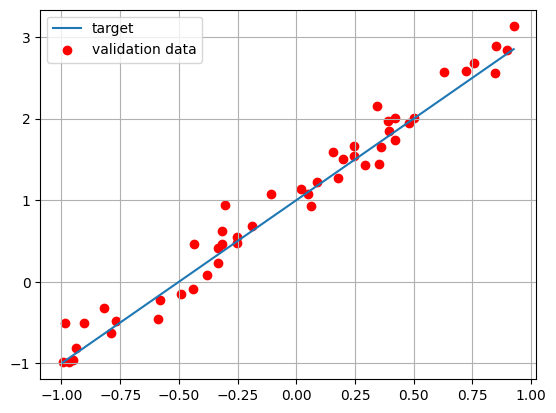

In [3]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label="target")
plt.scatter(x_valid, y_valid, color="r", label="validation data")
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let"s start using a simple Sequential model with just one layer on one neuron only!

In [ ]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer="sgd", loss="mse", metrics=["mse"])

In [5]:
# get a summary of our composed model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [5]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.3928 - mse: 4.3928 - val_loss: 3.4550 - val_mse: 3.4550
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3528 - mse: 3.3528 - val_loss: 2.6712 - val_mse: 2.6712
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6054 - mse: 2.6054 - val_loss: 2.0988 - val_mse: 2.0988
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0529 - mse: 2.0529 - val_loss: 1.6630 - val_mse: 1.6630
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6299 - mse: 1.6299 - val_loss: 1.3285 - val_mse: 1.3285
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3044 - mse: 1.3044 - val_loss: 1.0671 - val_mse: 1.0671
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0488 - mse: 1.0488 - val_loss: 0.8584 - val_mse: 0.8584
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8454 - mse: 0.8454 - val_loss: 0.6958 - val_mse: 0.6958
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6861 - mse:

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [6]:
# return weights and biases
model.get_weights()

[array([[1.8898413]], dtype=float32), array([0.97750664], dtype=float32)]

In [7]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0481 - mse: 0.0481

Test loss: 0.048119720071554184
Test accuracy: 0.048119720071554184


In [8]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0041 - mse: 0.0041

Test loss: 0.004117491189390421
Test accuracy: 0.004117491189390421


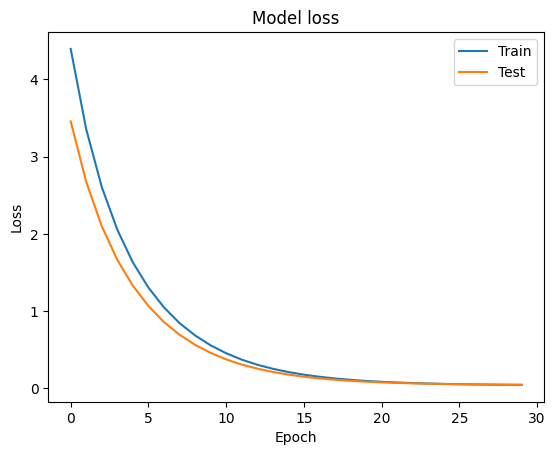

In [9]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Test"], loc="best")
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


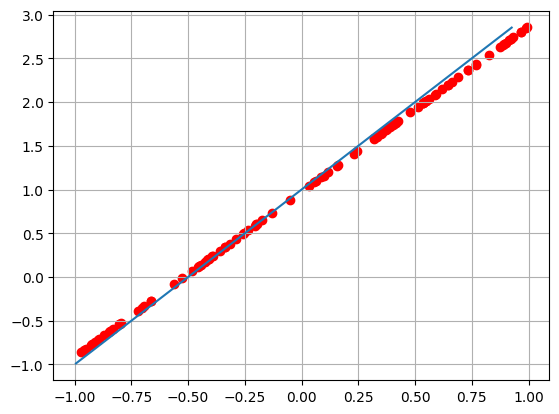

In [10]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color="r")
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

The starting model has $N_\text{epochs}=30$, $N_\text{train}=500$ and $\sigma=0.2$. It returns a fit with a test loss of $0.0445$ on the noisy validation data and of $0.000488$ on the exact curve.

In [ ]:
def linear_model():
    model = tf.keras.Sequential()
    model.add(Input(shape=(1,)))
    model.add(Dense(1))

    model.compile(optimizer="sgd", loss="mse", metrics=["mse"])
    
    return model

def train_model(model, N_epochs, N_train, sigma):
    m = 2
    b = 1
    
    np.random.seed(0)
    x_train = np.random.uniform(-1, 1, N_train)
    x_valid = np.random.uniform(-1, 1, 50)
    x_valid.sort()
    y_target = m * x_valid + b # ideal (target) linear function

    y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
    y_valid = np.random.normal(m * x_valid + b, sigma)

    return model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=N_epochs,
          shuffle=True,
          validation_data=(x_valid, y_valid)) , model.evaluate(x_valid, y_valid, batch_size=32, verbose=0), model.evaluate(x_valid, y_target, batch_size=32, verbose=0)

In [60]:
model = linear_model()
history, _, _ = train_model(model, 70, 500, 0.2)

sigmas = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
n_train = [100, 500, 1000, 2000, 5000, 10000]
sigma_losses = []
train_losses = []

for sigma in sigmas:
    model = linear_model()
    _, score_valid, score_target = train_model(model, 30, 500, sigma)
    sigma_losses.append([score_valid[0], score_target[0]])

for n in n_train:
    model = linear_model()
    _, score_valid, score_target = train_model(model, 30, n, 0.2)
    train_losses.append([score_valid[0], score_target[0]])

sigma_losses = np.array(sigma_losses)
train_losses = np.array(train_losses)

Epoch 1/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4975 - mse: 1.4975 - val_loss: 1.1852 - val_mse: 1.1852
Epoch 2/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0199 - mse: 1.0199 - val_loss: 0.8253 - val_mse: 0.8253
Epoch 3/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7226 - mse: 0.7226 - val_loss: 0.5990 - val_mse: 0.5990
Epoch 4/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5337 - mse: 0.5337 - val_loss: 0.4523 - val_mse: 0.4523
Epoch 5/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4089 - mse: 0.4089 - val_loss: 0.3498 - val_mse: 0.3498
Epoch 6/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3209 - mse: 0.3209 - val_loss: 0.2781 - val_mse: 0.2781
Epoch 7/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2580 - mse: 0.2580 - val_loss: 0.2247 - val_mse: 0.2247
Epoch 8/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2107 - mse: 0.2107 - val_loss: 0.1854 - val_mse: 0.1854
Epoch 9/70
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1750 - mse:

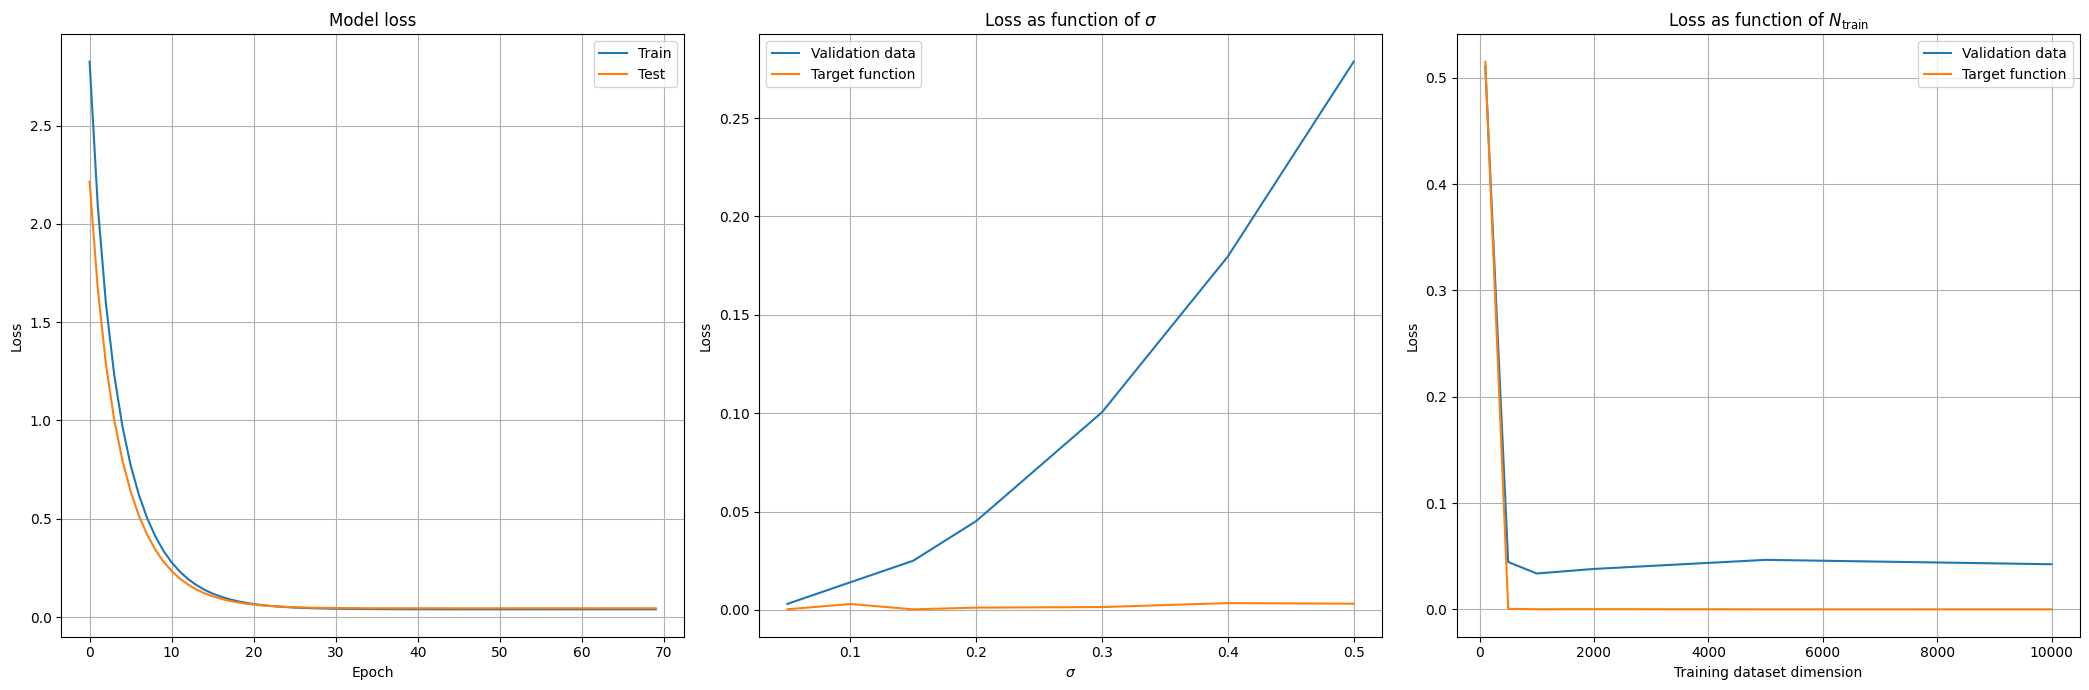

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(21,7))

axs[0].plot(history.history["loss"], label="Train")
axs[0].plot(history.history["val_loss"], label="Test")
axs[0].set_title("Model loss")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")

axs[1].plot(sigmas, sigma_losses[:,0], label="Validation data")
axs[1].plot(sigmas, sigma_losses[:,1], label="Target function")
axs[1].set_xlabel("$\\sigma$")
axs[1].set_ylabel("Loss")
axs[1].set_title("Loss as function of $\\sigma$")

axs[2].plot(n_train, train_losses[:,0], label="Validation data")
axs[2].plot(n_train, train_losses[:,1], label="Target function")
axs[2].set_xlabel("Training dataset dimension")
axs[2].set_ylabel("Loss")
axs[2].set_title("Loss as function of $N_\\text{train}$")

for ax in axs:
    ax.legend()
    ax.grid()

plt.tight_layout();

By changing only the number of epochs the figure shows that the validation loss converges to a constant value after $N_\text{epochs}\approx20$, so for the simulations it was used value of $N_\text{epochs}=30$. By changing only $\sigma$ or $N_\text{train}$ we can visualize the validation loss as a function of the parameters.

As $\sigma$ increases the validation loss also increases because the validation data becomes more noisy and more difficult to fit, while the target loss (loss evaluating the target function) only rises slightly. This means that the neural network is able to fit the target function over the noise of the validation data, and since the validation data is far from the target the validation loss rises.

As $N_\text{train}$ rises the validation and target loss goes down to an almost constant value, after which the increased dimension of the training values have little effect on the target function loss, if not the effect of increasing the training time.

With this analysis the previous result can be improved by choosing $N_\text{epochs}=40$, $\sigma=0.15$, $N_\text{train}=1000$.

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6697 - mse: 0.6697 - val_loss: 0.3225 - val_mse: 0.3225
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2244 - mse: 0.2244 - val_loss: 0.1235 - val_mse: 0.1235
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0944 - mse: 0.0944 - val_loss: 0.0614 - val_mse: 0.0614
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0512 - mse: 0.0512 - val_loss: 0.0419 - val_mse: 0.0419
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0365 - mse: 0.0365 - val_loss: 0.0337 - val_mse: 0.0337
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0301 - mse: 0.0301 - val_loss: 0.0292 - val_mse: 0.0292
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0266 - mse: 0.0266 - val_loss: 0.0263 - val_mse: 0.0263
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0246 - mse: 0.0246 - val_loss: 0.0243 - val_mse: 0.0243
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0235 - mse: 

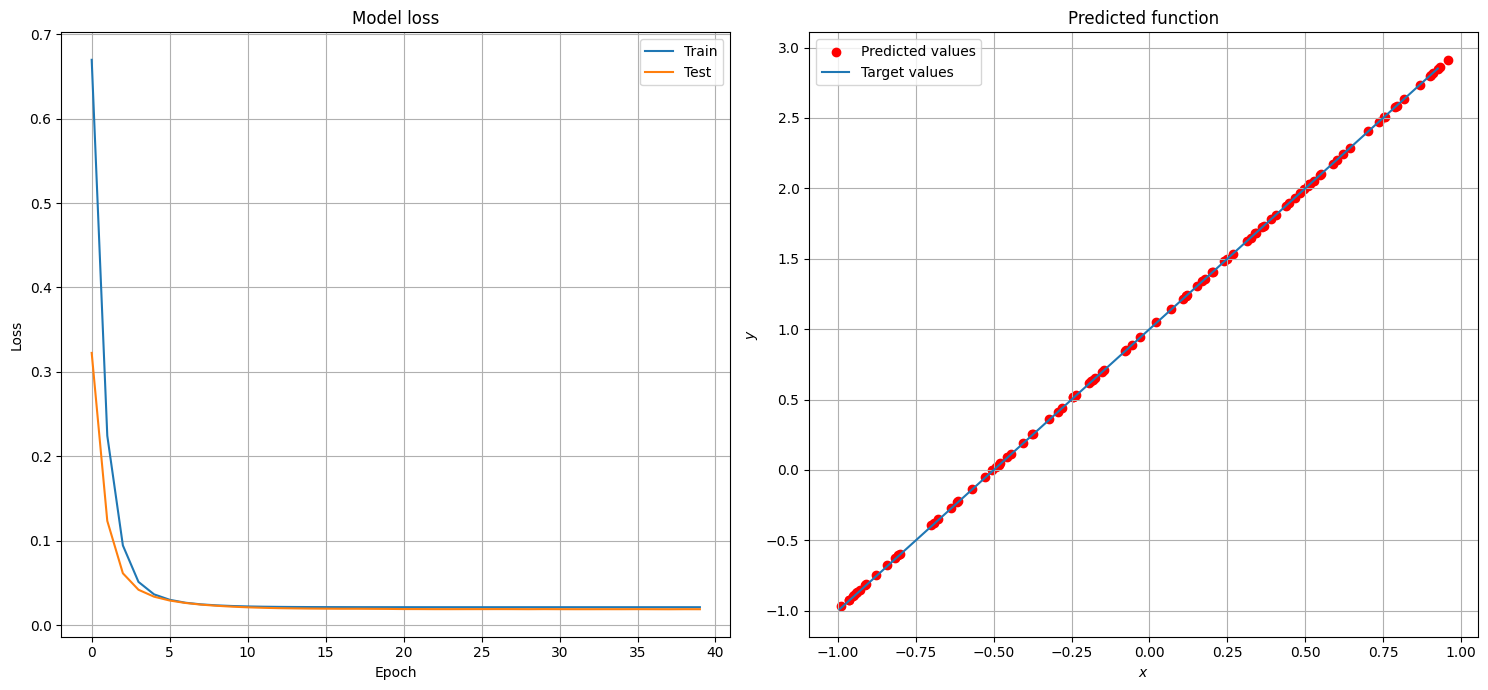

In [61]:
model = linear_model()
history, score_val, score_target = train_model(model, 40, 1000, 0.15)

fig, axs = plt.subplots(1, 2, figsize=(15, 7))

axs[0].plot(history.history["loss"], label="Train")
axs[0].plot(history.history["val_loss"], label="Test")
axs[0].set_title("Model loss")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")

x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
axs[1].scatter(x_predicted, y_predicted,color="r", label="Predicted values")
axs[1].plot(x_valid, y_target, label="Target values")
axs[1].set_title("Predicted function")
axs[1].set_ylabel("$y$")
axs[1].set_xlabel("$x$")

for ax in axs:
    ax.legend()
    ax.grid()
plt.tight_layout()

print(f"Validation loss = {score_val[0]}")
print(f"Target loss = {score_target[0]}")

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set?
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

In [62]:
def f(x):
    return 4 -3 * x - 2 * np.power(x, 2) + 3 * np.power(x, 3)

In [69]:
# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 5000)
x_valid = np.random.uniform(-1, 1, 500)
x_valid.sort()
y_target = f(x_valid) # ideal (target) linear function

sigma = 0.15 # noise standard deviation
y_train = np.random.normal(f(x_train), sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(f(x_valid), sigma)

In [ ]:
model = tf.keras.Sequential()

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(16,activation="tanh"))
model.add(Dense(8,activation="tanh"))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer="adam", loss="mse", metrics=["mse"])

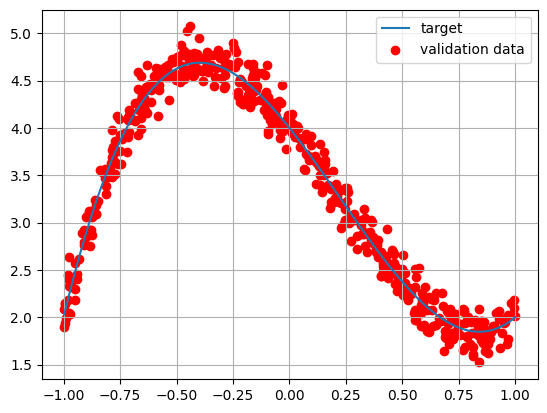

In [138]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label="target")
plt.scatter(x_valid, y_valid, color="r", label="validation data")
plt.legend()
plt.grid(True)
plt.show()

In [148]:
history = model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=40,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7041 - mse: 6.7041 - val_loss: 1.2398 - val_mse: 1.2398
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5448 - mse: 0.5448 - val_loss: 0.4259 - val_mse: 0.4259
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3986 - mse: 0.3986 - val_loss: 0.4076 - val_mse: 0.4076
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3759 - mse: 0.3759 - val_loss: 0.3754 - val_mse: 0.3754
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3327 - mse: 0.3327 - val_loss: 0.3147 - val_mse: 0.3147
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2725 - mse: 0.2725 - val_loss: 0.2510 - val_mse: 0.2510
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2036 - mse: 0.2036 - val_loss: 0.1762 - val_mse: 0.1762
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1365 - mse: 0.1365 - val_loss: 0.1209 - val_mse: 0.1209
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


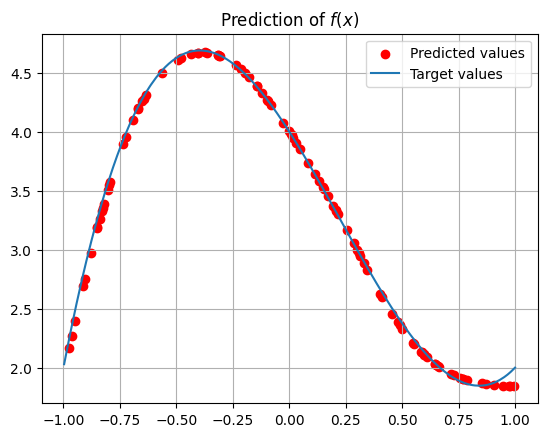

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mse: 0.0017 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.4298 - mse: 26.4298 
Loss inside the training range: 0.0017184775788336992
Loss outside the training range (x in [1,2]): 26.429824829101562


In [146]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color="r", label="Predicted values")
plt.plot(x_valid, y_target, label="Target values")
plt.title("Prediction of $f(x)$")
plt.legend()
plt.grid(True)
plt.show()

score_inside = model.evaluate(x_predicted, f(x_predicted), batch_size=32, verbose=1)
x_outside = np.random.uniform(1, 2, 100)
score_outside = model.evaluate(x_outside, f(x_outside), batch_size=32, verbose=1)

print(f"Loss inside the training range: {score_inside[0]}")
print(f"Loss outside the training range (x in [1,2]): {score_outside[0]}")

To approximate $f(x)$ I created a model with 2 layers of 16 and 8 neurons with a tanh activation function, since it was the one that gives the better approximation of the function with a low number of neurons because the function has smooth curves. As the optimizer I chose the Adam optimizer because it converges to the minimum validation loss quicker than the SGD. As loss function I used the mean square error. The model manages to fit most of the function in the interval [-1,1], but it has a problem in fitting the minimum at the right of the interval. The loss on newly generated data inside the training interval is small (0.0017), while the one on data outside of the training interval is very large (26.4). This shows that neural networks are not able to extrapolate outside of the data on which they are trained. By increasing the number of parameters the model fits the function increasingly well at the cost of the training time. 

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

In [149]:
def f(x, y):
    return np.sin(np.power(x, 2) + np.power(y, 2))

In [196]:
# generate training inputs
np.random.seed(0)
n_train = 10000
n_valid = 500
x_train = np.reshape(np.random.uniform(-1.5, 1.5, 2*n_train), (n_train,2))
x_valid = np.reshape(np.random.uniform(-1.5, 1.5, 2*n_valid), (n_valid,2))

y_target = f(x_valid[:,0], x_valid[:,1]) # ideal (target) linear function

sigma = 0.2 # noise standard deviation
y_train = np.random.normal(f(x_train[:,0], x_train[:,1]), sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(f(x_valid[:,0], x_valid[:,1]), sigma)

In [205]:
model = tf.keras.Sequential()

model = tf.keras.Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(64, activation="tanh"))
model.add(Dense(32, activation="tanh"))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer="adam", loss="mse", metrics=["mse"])

In [206]:
history = model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=40,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2117 - mse: 0.2117 - val_loss: 0.1871 - val_mse: 0.1871
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1925 - mse: 0.1925 - val_loss: 0.1916 - val_mse: 0.1916
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1918 - mse: 0.1918 - val_loss: 0.1909 - val_mse: 0.1909
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1901 - mse: 0.1901 - val_loss: 0.1885 - val_mse: 0.1885
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1903 - mse: 0.1903 - val_loss: 0.1858 - val_mse: 0.1858
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1895 - mse: 0.1895 - val_loss: 0.1895 - val_mse: 0.1895
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1886 - mse: 0.1886 - val_loss: 0.1818 - val_mse: 0.1818
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1798 - mse: 0.1798 - val_loss: 0.1644 - val_mse: 0.1644
Epoch 9/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step


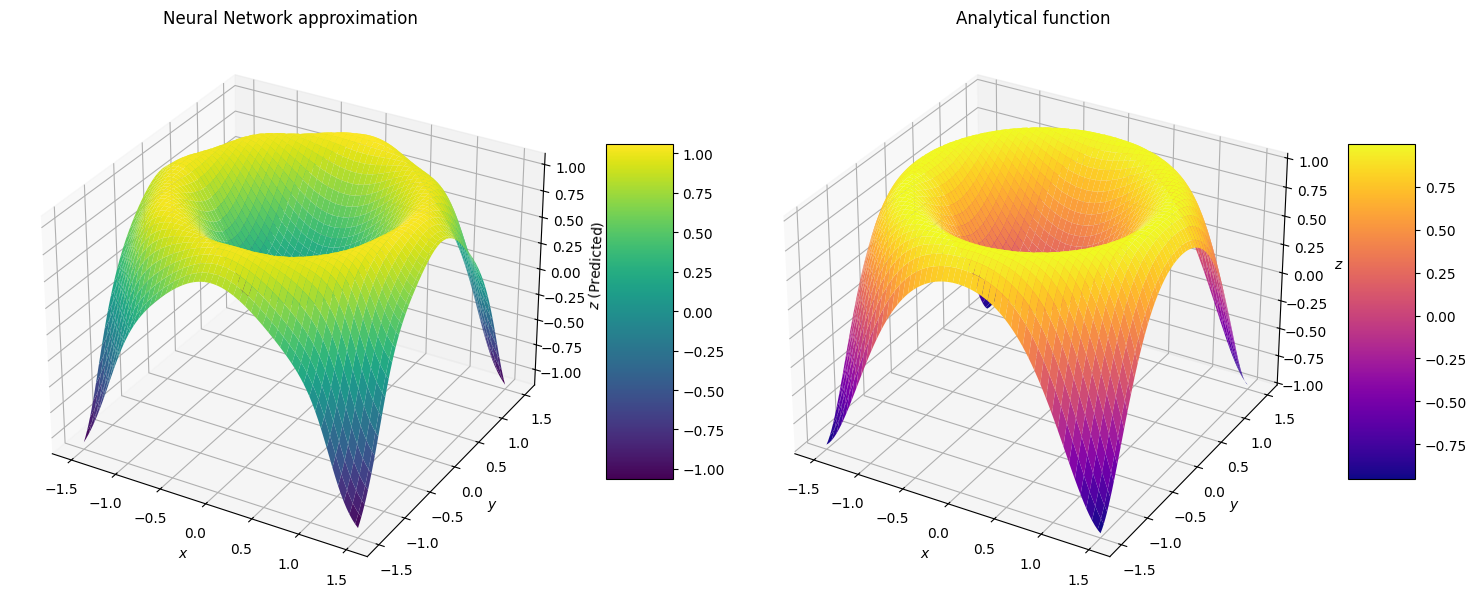

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mse: 0.0020 
Loss of the test data: 0.0019675828516483307


In [207]:
x_space = np.linspace(-1.5, 1.5, 100)
y_space = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x_space, y_space)
xy_grid = np.vstack([X.flatten(), Y.flatten()]).T

Z_pred = model.predict(xy_grid)
Z_pred = Z_pred.reshape(X.shape)

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(121, projection="3d")

surf = ax.plot_surface(X, Y, Z_pred, cmap="viridis", edgecolor="none")

ax.set_title("Neural Network approximation")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$ (Predicted)")
fig.colorbar(surf, shrink=0.5, aspect=5)

ax = fig.add_subplot(122, projection="3d")

surf = ax.plot_surface(X, Y, f(X, Y), cmap="plasma", edgecolor="none")

ax.set_title("Analytical function")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

xy_test = np.reshape(np.random.uniform(-1.5, 1.5, 200), shape=(100,2))
z_test = f(xy_test[:,0], xy_test[:,1])
score = model.evaluate(xy_test, z_test, batch_size=32, verbose=1)
print(f"Loss of the test data: {score[0]}")


To fit a more complex function like this more data points and more neurons are necessary. I chose tanh as the activation function because it has similarities with the fitted function, since they are both trigonometric functions. The graph of the predicted function is close to the analytical one, and the loss function over a set of 100 points is small (0.0020).